In [1]:
import numpy as np
import matplotlib.pyplot  as plt


/home/leoperes/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [32]:
reference_file = "RateAnalysis_data/reference_run_039529.npz"
equalized = "RateAnalysis_data/equalized_run_039518.npz"


In [36]:
data = np.load(reference_file)

print(data.files)

['run', 'channels', 'amplitude_bin_edges_adc', 'live_time_s', 'amplitude_definition', 'baseline_range', 'signal_range', 'tick_seconds', 'sample_type', 'frequency_khz', 'histogram_counts', 'histogram_rate_hz']


In [34]:
def load_npz(file):
    with np.load(file, allow_pickle=False) as data:
        channels = data["channels"]
        bin_edges = data["amplitude_bin_edges_adc"]
        try:
            histogram_rate_hz = data["histogram_rate_hz"]
            frequencies_khz = data["frequency_khz"]
            return channels, bin_edges,histogram_rate_hz,frequencies_khz
        except KeyError:
            histogram_before_rate_hz =  data["histogram_before_rate_hz"]
            histogram_after_rate_hz =  data["histogram_after_rate_hz"]
            frequencies_before_khz =  data["frequency_before_khz"]
            frequencies_after_khz =  data["frequency_after_khz"]
            return channels, bin_edges,histogram_before_rate_hz,histogram_after_rate_hz,frequencies_before_khz,frequencies_after_khz


Reference index: 2
Equalized index: 2


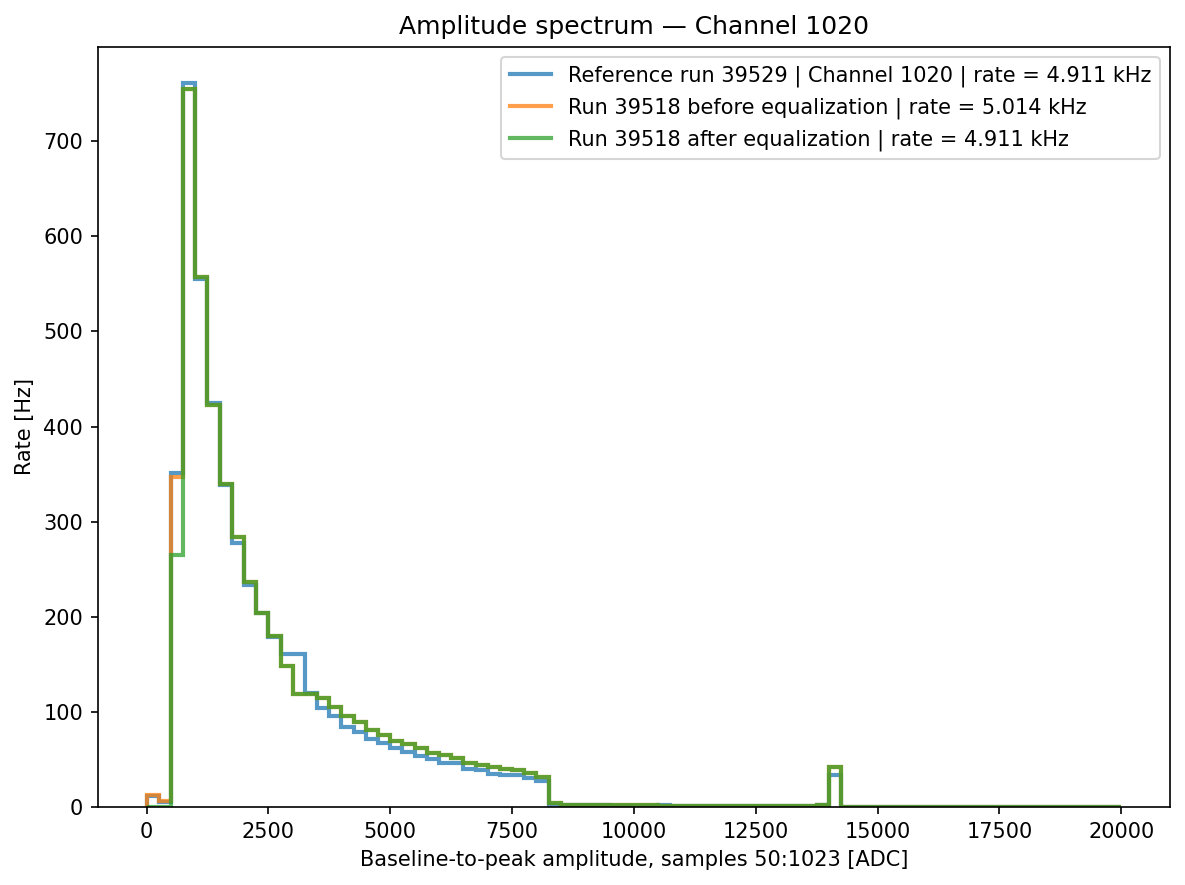

In [41]:
channel_to_plot = 1020

chs_ref, bin_ref, hist_ref, freq_ref = load_npz(reference_file)

(
    chs_eq,
    bin_eq,
    hist_before_eq,
    hist_after_eq,
    freq_before_eq,
    freq_after_eq,
) = load_npz(equalized)


def find_channel_index(channels, channel, dataset_name):
    matches = np.flatnonzero(channels == channel)

    if matches.size == 0:
        raise ValueError(
            f"Channel {channel} is not present in {dataset_name}"
        )

    return matches[0]


index_ref = find_channel_index(
    chs_ref,
    channel_to_plot,
    "reference data",
)

index_eq = find_channel_index(
    chs_eq,
    channel_to_plot,
    "equalized data",
)

print("Reference index:", index_ref)
print("Equalized index:", index_eq)

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

ax.stairs(
    hist_ref[index_ref],
    bin_ref,
    linewidth=2,
    alpha=0.75,
    label=(
        f"Reference run 39529 | Channel {channel_to_plot} | "
        f"rate = {freq_ref[index_ref]:.3f} kHz"
    ),
)

ax.stairs(
    hist_before_eq[index_eq],
    bin_eq,
    linewidth=2,
    alpha=0.75,
    label=(
        f"Run 39518 before equalization | "
        f"rate = {freq_before_eq[index_eq]:.3f} kHz"
    ),
)

ax.stairs(
    hist_after_eq[index_eq],
    bin_eq,
    linewidth=2,
    alpha=0.75,
    label=(
        f"Run 39518 after equalization | "
        f"rate = {freq_after_eq[index_eq]:.3f} kHz"
    ),
)

ax.set_title(
    f"Amplitude spectrum — Channel {channel_to_plot}"
)
ax.set_xlabel(
    "Baseline-to-peak amplitude, samples 50:1023 [ADC]"
)
ax.set_ylabel("Rate [Hz]")
ax.legend()

fig.tight_layout()
fig.savefig(
    f"reference_histogram_channel_{channel_to_plot}.png",
    bbox_inches="tight",
)
plt.show()